# Agent 1 — Transaction Anomaly Detector

Isolation Forest anomaly detector, converted from `agent1_anomaly_detector.py`.

**What this notebook fixes vs. the original `train_models.py`:**

1. **Trivially separable data.** The old generator put normal amounts in `[100, 50k]` and anomalies in `[500k, 2M]` with a $458k empty gap — the task was "is amount > 100k", not "detect anomalies". A depth-1 stump scored F1 = 1.0.
2. **No evaluation.** The old model was `.fit()` on 100% of the data and pickled — no train/test split, no metric.
3. **Leaky feature.** `amount / amount.mean()` — the mean is dominated by injected mega-anomalies, so the scaler shifts every refresh.
4. **Mis-typed categoricals.** `pd.factorize()` made Isolation Forest split currencies as if `CAD > USD`.
5. **`contamination=0.1`** was hard-wired to the exact injection rate.

This notebook trains on the realistic `_v2` data, uses stable features, an honest train/test split, ROC-AUC + average precision, a tuned threshold, and a separability self-check.

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             f1_score, classification_report,
                             roc_curve, precision_recall_curve)
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
# Notebook lives in ml/ ; data and models are siblings of ml/'s parent.
HERE = os.getcwd()
DATA_DIR = os.path.join(HERE, '..', 'data')
MODELS_DIR = os.path.join(HERE, '..', 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

# Prefer the realistic v2 data; fall back to the original if not generated.
DATA_FILE = os.path.join(DATA_DIR, 'historical_transactions_v2.csv')
if not os.path.exists(DATA_FILE):
    DATA_FILE = os.path.join(DATA_DIR, 'historical_transactions.csv')
print('data file:', os.path.basename(DATA_FILE))

data file: historical_transactions_v2.csv


## Feature engineering

Stable, model-appropriate features — no leaky mean, no fake ordinals.

In [3]:
def build_features(df):
    """Stable, model-appropriate features (no leaky mean, no fake ordinals)."""
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['is_offhours'] = (~df['hour'].between(8, 18)).astype(int)

    # log-amount: stable and bounded, unlike amount / amount.mean().
    df['log_amount'] = np.log1p(df['amount'])

    # How big is this txn vs what is TYPICAL for this counterparty?
    cp_median = df.groupby('counterparty_name')['amount'].transform('median')
    df['amount_vs_cp_typical'] = df['amount'] / cp_median.clip(lower=1.0)

    numeric = ['log_amount', 'amount_vs_cp_typical', 'hour',
               'day_of_week', 'is_offhours']
    # One-hot encode categoricals instead of arbitrary integer codes.
    cats = pd.get_dummies(df[['transaction_type', 'currency']],
                          prefix=['type', 'ccy'])
    X = pd.concat([df[numeric], cats.astype(float)], axis=1)
    return X.fillna(0.0)

In [4]:
df = pd.read_csv(DATA_FILE)
X = build_features(df)
y = df['is_anomaly'].astype(int)
print(f'rows={len(df)}  features={X.shape[1]}  anomaly rate={y.mean():.3f}')
X.head()

rows=1000  features=14  anomaly rate=0.101


,log_amount,amount_vs_cp_typical,hour,day_of_week,is_offhours,type_ach_transfer,type_fee,type_internal_transfer,type_wire_payment,ccy_CAD,ccy_EUR,ccy_GBP,ccy_JPY,ccy_USD
0,13.450059,17.225167,11,4,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,10.180212,1.209431,9,1,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,9.826076,0.675691,8,6,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,9.627467,0.695848,13,3,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,13.122155,18.249019,21,3,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## Separability check

Is the task still trivially easy? A depth-1 stump scoring F1 ≈ 1.0 means the data is fake.

In [5]:
stump = DecisionTreeClassifier(max_depth=1, random_state=42)
stump_f1 = cross_val_score(stump, df[['amount']], y, cv=5, scoring='f1').mean()
print(f'[separability] depth-1 stump on `amount` alone, 5-fold F1 = {stump_f1:.3f}')
if stump_f1 > 0.98:
    print('  >> WARNING: data is trivially separable -- metrics below are')
    print('     meaningless. Regenerate with ml/generate_data.py.')
else:
    print('  >> OK: classes overlap, the task is non-trivial.')

[separability] depth-1 stump on `amount` alone, 5-fold F1 = 0.873
  >> OK: classes overlap, the task is non-trivial.


## Honest train/test split + Isolation Forest

Isolation Forest is unsupervised: it sees only `X_tr`, never the labels.

In [6]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

iso = IsolationForest(n_estimators=300, contamination='auto',
                      random_state=42, n_jobs=-1)
iso.fit(X_tr)

# Higher score = more anomalous.
train_score = -iso.score_samples(X_tr)
test_score = -iso.score_samples(X_te)

auc = roc_auc_score(y_te, test_score)
ap = average_precision_score(y_te, test_score)

In [7]:
# Tune the alert threshold on the TRAIN fold (best F1) -- not assumed.
# NOTE: best_f1 / best_thr are now initialised before the loop
#       (the original .py used them undefined -- a NameError bug).
best_f1, best_thr = -1.0, float(np.median(train_score))
for thr in np.quantile(train_score, np.linspace(0.5, 0.99, 50)):
    f1 = f1_score(y_tr, (train_score >= thr).astype(int))
    if f1 > best_f1:
        best_f1, best_thr = f1, thr
test_pred = (test_score >= best_thr).astype(int)

print('--- Held-out test performance (Isolation Forest) ---')
print(f'ROC-AUC                : {auc:.3f}')
print(f'Average precision (PR) : {ap:.3f}')
print(f'Tuned threshold        : {best_thr:.4f}  (chosen on train fold)')
print(classification_report(y_te, test_pred, digits=3,
                            target_names=['normal', 'anomaly']))

--- Held-out test performance (Isolation Forest) ---
ROC-AUC                : 0.972
Average precision (PR) : 0.863
Tuned threshold        : 0.5769  (chosen on train fold)
              precision    recall  f1-score   support

      normal      0.969     0.987     0.978       225
     anomaly      0.857     0.720     0.783        25

    accuracy                          0.960       250
   macro avg      0.913     0.853     0.880       250
weighted avg      0.958     0.960     0.958       250



## Plots — score distribution, ROC, precision-recall

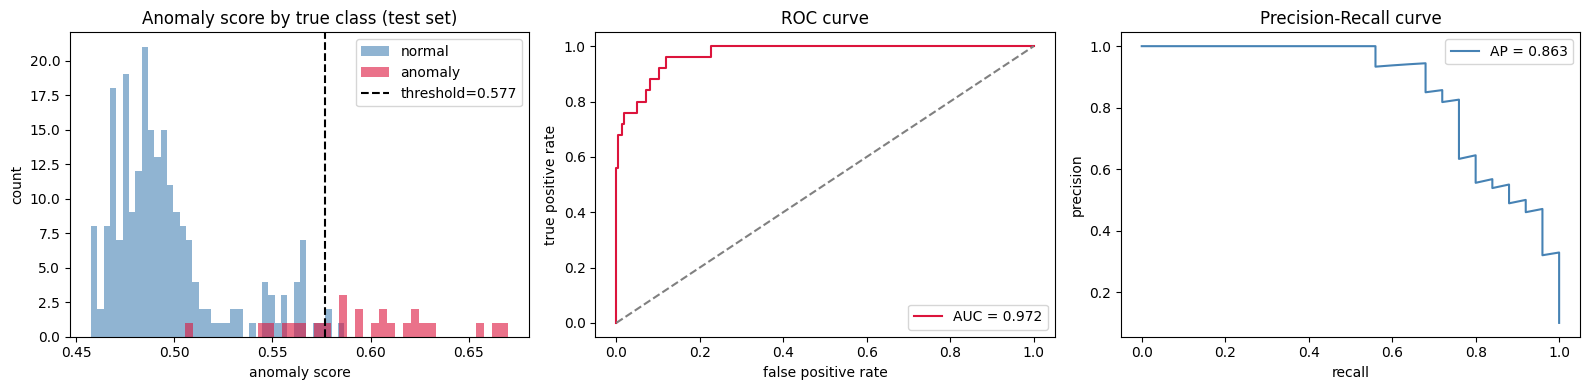

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. anomaly score distribution by true class
ax = axes[0]
ax.hist(test_score[y_te.values == 0], bins=40, alpha=0.6,
        label='normal', color='steelblue')
ax.hist(test_score[y_te.values == 1], bins=40, alpha=0.6,
        label='anomaly', color='crimson')
ax.axvline(best_thr, color='black', ls='--',
           label=f'threshold={best_thr:.3f}')
ax.set_title('Anomaly score by true class (test set)')
ax.set_xlabel('anomaly score'); ax.set_ylabel('count'); ax.legend()

# 2. ROC curve
fpr, tpr, _ = roc_curve(y_te, test_score)
ax = axes[1]
ax.plot(fpr, tpr, color='crimson', label=f'AUC = {auc:.3f}')
ax.plot([0, 1], [0, 1], '--', color='gray')
ax.set_title('ROC curve'); ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate'); ax.legend()

# 3. precision-recall curve
prec, rec, _ = precision_recall_curve(y_te, test_score)
ax = axes[2]
ax.plot(rec, prec, color='steelblue', label=f'AP = {ap:.3f}')
ax.set_title('Precision-Recall curve'); ax.set_xlabel('recall')
ax.set_ylabel('precision'); ax.legend()

plt.tight_layout(); plt.show()

In [9]:
if auc > 0.995:
    print('>> NOTE: AUC ~1.0 means the data is still too easy; trust this')
    print('   model only after testing on REAL transactions.')
else:
    print('>> Realistic AUC -- model has learned a non-trivial signal.')

>> Realistic AUC -- model has learned a non-trivial signal.


## Retrain on all data and serialise the model

The pickle is a **dict**: `model` + `feature_names` + tuned threshold + metrics — not a bare estimator.

In [10]:
final = IsolationForest(n_estimators=300, contamination='auto',
                        random_state=42, n_jobs=-1)
final.fit(X)
bundle = {
    'model': final,
    'feature_names': list(X.columns),
    'alert_threshold': float(best_thr),
    'test_roc_auc': float(auc),
    'test_avg_precision': float(ap),
}
out = os.path.join(MODELS_DIR, 'anomaly_detector.pkl')
with open(out, 'wb') as f:
    pickle.dump(bundle, f)
print(f'Saved {out}')
print('  (pickle is a dict: model + feature_names + tuned threshold + metrics)')

Saved C:\CATAS\CATAS\ml\..\models\anomaly_detector.pkl
  (pickle is a dict: model + feature_names + tuned threshold + metrics)
